In [1]:
# imports

import os
import shutil
from pathlib import Path
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch

SEED = 38

torch.manual_seed(SEED)
np.random.seed(SEED)

In [2]:
target = Path("data/metadata.csv")     # metadata file relative location

if not target.exists():    # if it doesn't exist, create it
    def create_metadata():
        # paths to all folders
        celeb_real = Path("raw_datasets/Celeb-real")
        celeb_fake = Path("raw_datasets/Celeb-synthesis")
        ff_real = Path("raw_datasets/FaceForensics++_C23/original")
        ff_fake = Path("raw_datasets/FaceForensics++_C23")
        ff_fake_dirs = ["Deepfakes", "Face2Face", "FaceShifter", "FaceSwap", "NeuralTextures"]
    
        data = []

        # root folder to dataset
        base_dir = Path("data")

        # list celeb-df data
        for vid in celeb_real.glob("*.mp4"):
            data.append({
                "path": str(vid),
                "source": "Celeb-DF",
                "method": "-",
                "label": 0
            })
    
        for vid in celeb_fake.glob("*.mp4"):
            data.append({
                "path": str(vid),
                "source": "Celeb-DF",
                "method": "NA",
                "label": 1
            })

        # list FF++ data
        for vid in ff_real.glob("*.mp4"):
            data.append({
                "path": str(vid),
                "source": "FF++",
                "method": "-",
                "label": 0
            })
    
        for dirs in ff_fake_dirs:
            for vid in (ff_fake/dirs).glob("*.mp4"):
                data.append({
                "path": str(vid),
                "source": "FF++",
                "method": str(dirs),
                "label": 1
            })

        # make a dataframe and store it as csv for future use
        df = pd.DataFrame(data);
        Path("data").mkdir(exist_ok=True)
        df.to_csv(target, index=False)


        #indicate completion
        print("**************************")
        print("Metadata Created Successfully")
        print("**************************")
    
    
    create_metadata()   # runs only when metadata.csv doesn't exist

In [3]:
df = pd.read_csv("data/metadata.csv")
df      #view the data frame

,path,source,method,label
0,raw_datasets\Celeb-real\id0_0000.mp4,Celeb-DF,-,0
1,raw_datasets\Celeb-real\id0_0001.mp4,Celeb-DF,-,0
2,raw_datasets\Celeb-real\id0_0002.mp4,Celeb-DF,-,0
3,raw_datasets\Celeb-real\id0_0003.mp4,Celeb-DF,-,0
4,raw_datasets\Celeb-real\id0_0004.mp4,Celeb-DF,-,0
...,...,...,...,...
12224,raw_datasets\FaceForensics++_C23\NeuralTexture...,FF++,NeuralTextures,1
12225,raw_datasets\FaceForensics++_C23\NeuralTexture...,FF++,NeuralTextures,1
12226,raw_datasets\FaceForensics++_C23\NeuralTexture...,FF++,NeuralTextures,1
12227,raw_datasets\FaceForensics++_C23\NeuralTexture...,FF++,NeuralTextures,1


In [4]:
real_df = df[df["label"] == 0]
fake_df = df[df["label"] == 1]

print(len(real_df))
print(len(fake_df))

1590
10639


In [5]:
celeb_fake = fake_df[fake_df["source"] == "Celeb-DF"]
celeb_sample = celeb_fake.sample(800, random_state=SEED)

ff_fake = fake_df[fake_df["source"] == "FF++"]

deepfakes = ff_fake[ff_fake["method"] == "Deepfakes"].sample(160, random_state=SEED)
faceswap = ff_fake[ff_fake["method"] == "FaceSwap"].sample(160, random_state=SEED)
face2face = ff_fake[ff_fake["method"] == "Face2Face"].sample(160, random_state=SEED)
neural = ff_fake[ff_fake["method"] == "NeuralTextures"].sample(160, random_state=SEED)
faceshifter = ff_fake[ff_fake["method"] == "FaceShifter"].sample(160, random_state=SEED)

ff_sample = pd.concat([deepfakes, faceswap, face2face, neural, faceshifter])

df = pd.concat([real_df, celeb_sample, ff_sample])

In [6]:
# separate by source
celeb_df = df[df["source"]=="Celeb-DF"]
ff_df = df[df["source"]=="FF++"]

# shuffle it for better split
celeb_df = celeb_df.sample(frac=1, random_state=SEED)
ff_df = ff_df.sample(frac=1, random_state=SEED)

# determine train dataset split for both 
train_celeb_size = int(0.7 * len(celeb_df))
train_ff_size = int(0.7 * len(ff_df))

# concatenate train set from both sources evenly
train_df = pd.concat([celeb_df[:train_celeb_size], ff_df[:train_ff_size]]).reset_index(drop=True)

# repeat the same for val and test

val_test_celeb_size = int(0.15 * len(celeb_df))
val_test_ff_size = int(0.15 * len(ff_df))

val_df = pd.concat([celeb_df[train_celeb_size: train_celeb_size + val_test_celeb_size], ff_df[train_ff_size: train_ff_size + val_test_ff_size]]).reset_index(drop=True)
test_df = pd.concat([celeb_df[train_celeb_size + val_test_celeb_size:], ff_df[train_ff_size + val_test_ff_size:]]).reset_index(drop=True)


print("Train data:", len(train_df))
print("Val data:", len(val_df))
print("Test data:", len(test_df))

Train data: 2232
Val data: 478
Test data: 480


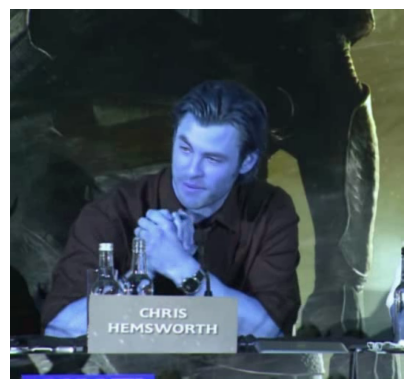

In [7]:
# frame extraction function to save frames in memory

def extract_frames(vid_path, num_frames = 10, resize=None):
    vid_path = Path(vid_path)

    cap = cv2.VideoCapture(str(vid_path))

    if not cap.isOpened():
        print(f"Error opening video: {vid_path}")
        return

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        print(f"No frames found in: {vid_path}")
        return

    interval = max(total_frames // num_frames, 1)

    frames = []
    frame_id = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_id % interval == 0:

            if resize is not None:
                frame = cv2.resize(frame, resize)

            frames.append(frame)

            if len(frames) >=  num_frames:
                break

        frame_id += 1

    cap.release()
    return frames

# function demo
output = extract_frames(train_df["path"][0])
plt.imshow(output[9])
plt.axis('off')
plt.show()

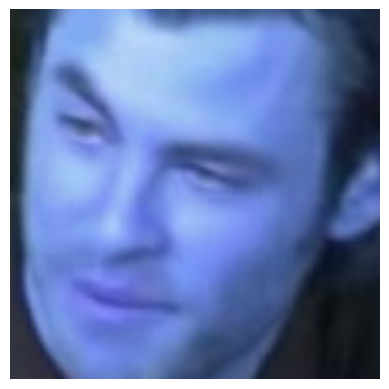

In [8]:
# face detection at frame 0 and face tracing on rest of frame for accurate crop

face_detector = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

def face_detect_trace(vid_path):
    faces = []

    frames = extract_frames(vid_path)

    first = frames[0]
    gray = cv2.cvtColor(first, cv2.COLOR_BGR2GRAY)

    detected = face_detector.detectMultiScale(gray, 1.3, 5)

    if len(detected) == 0:
        frames = [cv2.resize(f, (224, 224)) for f in frames]
        return frames

    x,y,w,h = detected[0]

    tracker = cv2.legacy.TrackerCSRT_create()
    tracker.init(first, (x,y,w,h))

    for frame in frames:
        h_frame, w_frame = frame.shape[:2]
        success, box = tracker.update(frame)

        if success:
            x,y,w,h = [int(v) for v in box]
            x = max(0, x)
            y = max(0, y)
            w = max(1, min(w, w_frame - x))
            h = max(1, min(h, h_frame - y))
            
            face = frame[y: y + h, x: x + w]

            if face is None or face.size == 0:
                face = cv2.resize(frame, (224, 224))
            else:
                face = cv2.resize(face, (224, 224))
            faces.append(face)
        else:
            frame = cv2.resize(frame, (224, 224))
            faces.append(frame)

    return faces

# function demo
faces = face_detect_trace(train_df["path"][0])

plt.imshow(faces[9])
plt.axis("off")
plt.show()

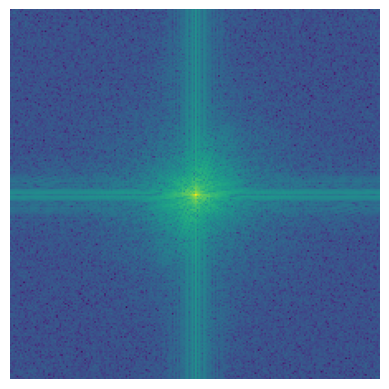

In [9]:
# applying frequency transform

def fft_transform(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    f = np.fft.fft2(gray)
    fshift = np.fft.fftshift(f)
    magnitude = np.log(np.abs(fshift) + 1)
    magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)
    return magnitude.astype(np.uint8)

# function demo
freq = fft_transform(faces[9])
plt.imshow(freq)
plt.axis("off")
plt.show()

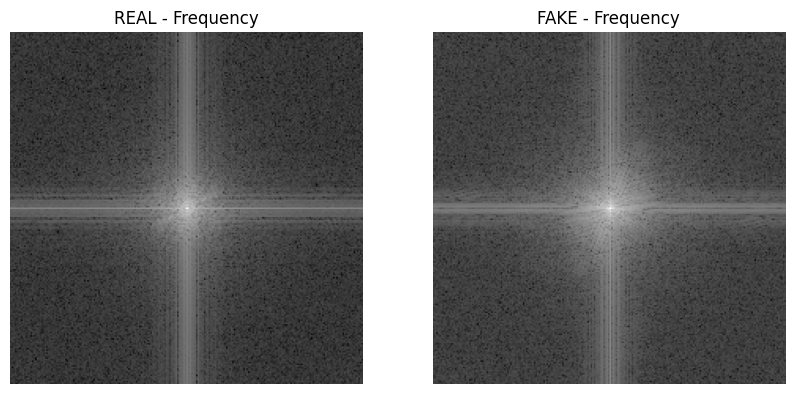

In [10]:
real_path = train_df[train_df["label"]==0].iloc[0]["path"]
real_faces = face_detect_trace(real_path)
real_freq = fft_transform(real_faces[9])

fake_path = train_df[train_df["label"]==1].iloc[0]["path"]
fake_faces = face_detect_trace(fake_path)
fake_freq = fft_transform(fake_faces[9])

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(real_freq, cmap="gray")
plt.title("REAL - Frequency")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(fake_freq, cmap="gray")
plt.title("FAKE - Frequency")
plt.axis("off")

plt.show()

In [11]:
save_dir = Path("preprocessed")
save_dir.mkdir(exist_ok=True)

mode_path = {
    "train": Path("train"),
    "val": Path("val"),
    "test": Path("test")
}

def save_preprocessed(df, mode, num_frames = 10):
    save_path = save_dir / mode_path[mode]
    save_path.mkdir(parents=True, exist_ok=True)

    for idx in range(len(df)):
        video_path = df.iloc[idx]["path"]
        label = df.iloc[idx]["label"]

        faces = face_detect_trace(video_path)
        
        if faces is None or len(faces) == 0:
            faces = [np.zeros((224, 224, 3), dtype=np.uint8) for _ in range(num_frames)]

        if len(faces) < num_frames:
            faces += [faces[-1]] * (num_frames - len(faces))

        freqs = [fft_transform(face) for face in faces]

        spatial = np.stack(faces)
        spatial = torch.tensor(spatial).permute(0, 3, 1, 2).float() / 255.0

        freqs = np.stack(freqs)
        freqs = torch.tensor(freqs).unsqueeze(1).float() / 255.0

        label = torch.tensor(label).float()

        data = {
            "spatial": spatial.half(),
            "frequency": freqs.half(),
            "label": label
        }

        label_str = "real" if label == 0 else "fake"

        fin_save = save_path / f"{label_str}_{idx}.pt"

        torch.save(data, fin_save)

        if idx % 10 == 0:
            print(f"Saved {idx}")

    print(f"{mode} dataset done")


In [12]:
save_preprocessed(df=val_df, mode="val")

Saved 0
Saved 10
Saved 20
Saved 30
Saved 40
Saved 50
Saved 60
Saved 70
Saved 80
Saved 90
Saved 100
Saved 110
Saved 120
Saved 130
Saved 140
Saved 150
Saved 160
Saved 170
Saved 180
Saved 190
Saved 200
Saved 210
Saved 220
Saved 230
Saved 240
Saved 250
Saved 260
Saved 270
Saved 280
Saved 290
Saved 300
Saved 310
Saved 320
Saved 330
Saved 340
Saved 350
Saved 360
Saved 370
Saved 380
Saved 390
Saved 400
Saved 410
Saved 420
Saved 430
Saved 440
Saved 450
Saved 460
Saved 470
val dataset done


In [13]:
save_preprocessed(df=test_df, mode="test")

Saved 0
Saved 10
Saved 20
Saved 30
Saved 40
Saved 50
Saved 60
Saved 70
Saved 80
Saved 90
Saved 100
Saved 110
Saved 120
Saved 130
Saved 140
Saved 150
Saved 160
Saved 170
Saved 180
Saved 190
Saved 200
Saved 210
Saved 220
Saved 230
Saved 240
Saved 250
Saved 260
Saved 270
Saved 280
Saved 290
Saved 300
Saved 310
Saved 320
Saved 330
Saved 340
Saved 350
Saved 360
Saved 370
Saved 380
Saved 390
Saved 400
Saved 410
Saved 420
Saved 430
Saved 440
Saved 450
Saved 460
Saved 470
test dataset done


In [ ]:
save_preprocessed(df=train_df, mode="train")

Saved 0
Saved 10
Saved 20
Saved 30
Saved 40
Saved 50
Saved 60
Saved 70
Saved 80
Saved 90
Saved 100
Saved 110
Saved 120
Saved 130
Saved 140
Saved 150
Saved 160
Saved 170
Saved 180
Saved 190
Saved 200
Saved 210
Saved 220
Saved 230
Saved 240
Saved 250
Saved 260
Saved 270
Saved 280
Saved 290
Saved 300
Saved 310
Saved 320
Saved 330
Saved 340
Saved 350
Saved 360
Saved 370
Saved 380
Saved 390
Saved 400
Saved 410
Saved 420
Saved 430
Saved 440
Saved 450
Saved 460
Saved 470
Saved 480
Saved 490
Saved 500
Saved 510
Saved 520
Saved 530
Saved 540
Saved 550
Saved 560
Saved 570
Saved 580
Saved 590
Saved 600
Saved 610
Saved 620
Saved 630
Saved 640
Saved 650
Saved 660
Saved 670
Saved 680
Saved 690
Saved 700
Saved 710
Saved 720
Saved 730
Saved 740
Saved 750
Saved 760
Saved 770
Saved 780
Saved 790
Saved 800
Saved 810
Saved 820
Saved 830
Saved 840
Saved 850
Saved 860
Saved 870
Saved 880
Saved 890
Saved 900
Saved 910
Saved 920
Saved 930
Saved 940
Saved 950
Saved 960
Saved 970
Saved 980
Saved 990
Saved 1000
